In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [5]:
splits = ['train[:80%]', 'train[80%:90%]', 'train[90%:]']

In [6]:
(train_ds, val_ds, test_ds), info = tfds.load(
    'malaria',
    split=splits,
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.9F78U9_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [7]:
for data in train_ds.take(3):
  print(data)

(<tf.Tensor: shape=(145, 148, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(133, 127, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

In [8]:

# Check how many images in each split
train_count = tf.data.experimental.cardinality(train_ds).numpy()
val_count = tf.data.experimental.cardinality(val_ds).numpy()
test_count = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Training images: {train_count}")   # Should be ~22,046
print(f"Validation images: {val_count}")   # Should be ~2,756
print(f"Testing images: {test_count}")     # Should be ~2,756


Training images: 22046
Validation images: 2756
Testing images: 2756


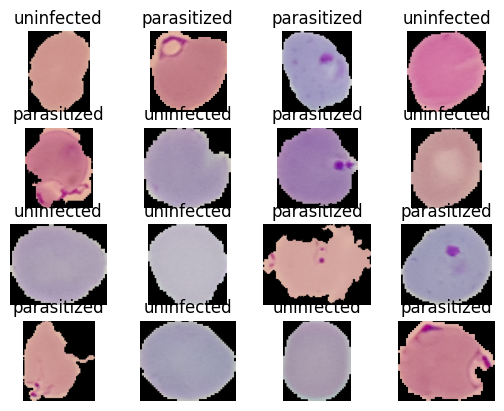

In [9]:
for i, (image,label) in enumerate(train_ds.take(16)):
  ax = plt.subplot(4,4, i + 1)
  plt.imshow(image)
  plt.title(info.features['label'].int2str(label))
  plt.axis('off')


In [10]:
info.features['label'].int2str(0)

'parasitized'

In [11]:
info.features['label'].int2str(1)

'uninfected'

In [12]:
# Preprocessing parameters
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(image, label):
    """Resize and normalize images"""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Batch, cache, and prefetch for performance
train_ds = train_ds.batch(BATCH_SIZE).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("Preprocessing complete!")
print(f"Image shape: {IMG_SIZE}x{IMG_SIZE}, Batch size: {BATCH_SIZE}")

Preprocessing complete!
Image shape: 128x128, Batch size: 32


In [14]:
# Data augmentation (applied only to training set)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

In [15]:
# Verify preprocessing - check a batch shape
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Min pixel: {tf.reduce_min(images):.4f}, Max pixel: {tf.reduce_max(images):.4f}")
    break

Batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Min pixel: 0.0000, Max pixel: 0.9014


In [16]:
# Build the Sequential CNN Model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # First Convolutional Block
    layers.Conv2D(
        filters=6,
        kernel_size=5,
        strides=1,
        padding='valid',
        activation='sigmoid',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    layers.MaxPooling2D(pool_size=2, strides=2),
    
    # Second Convolutional Block
    layers.Conv2D(
        filters=6,
        kernel_size=5,
        strides=1,
        padding='valid',
        activation='sigmoid'
    ),
    layers.MaxPooling2D(pool_size=2, strides=2),
    
    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(1000, activation='sigmoid'),
    layers.Dense(2, activation='sigmoid')
], name="malaria_cnn")

model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "malaria_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 58, 58, 6)      │           906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5046)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     5,047,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,050,364 (19.27 MB)

 Trainable params: 5,050,364 (19.27 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [18]:
# Train the model
EPOCHS = 20

# Add early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    # callbacks=[early_stopping]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.4966 - loss: 0.9920 - val_accuracy: 0.4888 - val_loss: 0.7070
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5031 - loss: 0.7061 - val_accuracy: 0.5112 - val_loss: 0.7279
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5053 - loss: 0.7014 - val_accuracy: 0.5112 - val_loss: 0.7160
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4946 - loss: 0.7073 - val_accuracy: 0.5112 - val_loss: 0.6948
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5068 - loss: 0.7081 - val_accuracy: 0.5112 - val_loss: 0.7336
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6103 - loss: 0.6565 - val_accuracy: 0.7173 - val_loss: 0.5583
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7224 - loss: 0.5416 - val_accuracy: 0.7827 - val_loss: 0.4553
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8494 - loss: 0.3451 - val_accuracy: 

In [19]:
# Evaluate on test set
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


=== Test Set Evaluation ===
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9460 - loss: 0.1847

Test Accuracy: 0.9452
Test Loss: 0.1834


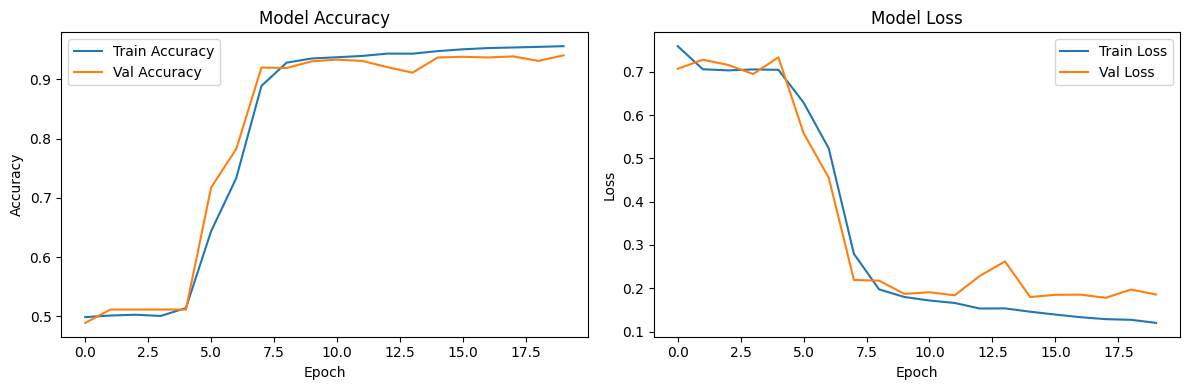

In [20]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


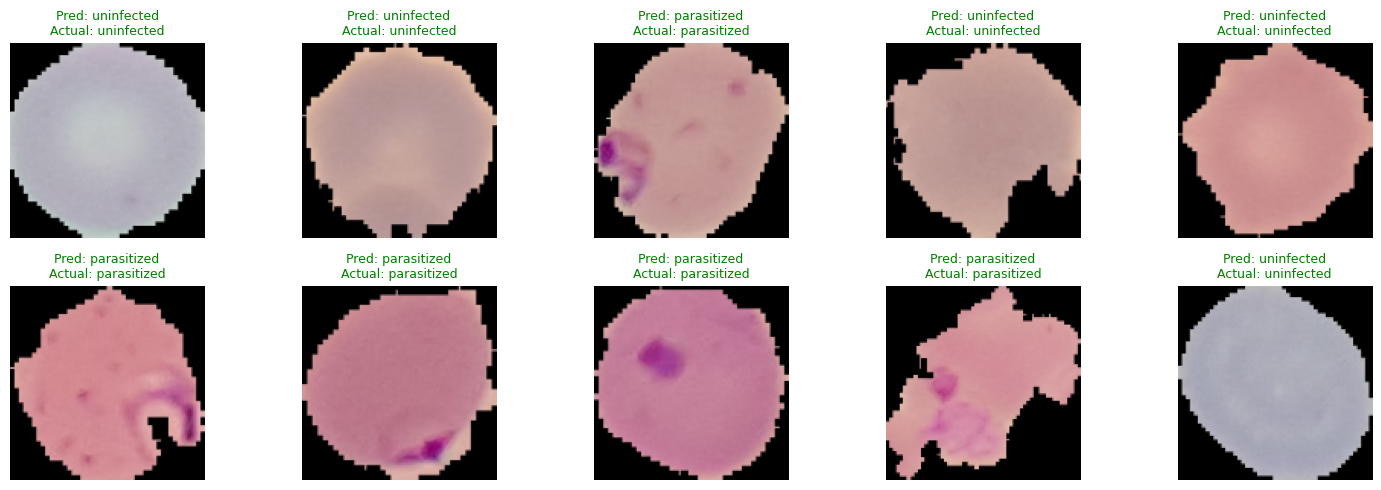

In [21]:
# Visualize predictions
plt.figure(figsize=(15, 5))

for i, (images, labels) in enumerate(test_ds.take(1)):
    predictions = model.predict(images)
    
    for j in range(10):
        plt.subplot(2, 5, j+1)
        plt.imshow(images[j])
        
        pred_label = np.argmax(predictions[j])
        actual_label = labels[j].numpy()
        
        color = 'green' if pred_label == actual_label else 'red'
        plt.title(f"Pred: {info.features['label'].int2str(pred_label)}\nActual: {info.features['label'].int2str(actual_label)}", 
                 color=color, fontsize=9)
        plt.axis('off')
    
    break

plt.tight_layout()
plt.show()

In [22]:
model.save("my_model.keras")

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [24]:
model.save("/content/drive/MyDrive/my_model.keras")

In [3]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my_model.keras")

In [26]:
!ls /content/drive/MyDrive/

'ABDUL BASIT.png'
'Black White Simple Photo Business Email Signature.png'
 Classroom
'Colab Notebooks'
'developing knowlwdge base using INSIGHT and EXPER....gsheet'
'facebook (1).png'
 facebook.png
 my_model.keras
'Red Modern Email Signature.png'
'Untitled document (1).gdoc'
'Untitled document.gdoc'
 vendor-sites.gsheet


In [13]:
# Evaluate on test set
print("\n=== Test Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


=== Test Set Evaluation ===
87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9460 - loss: 0.1847

Test Accuracy: 0.9452
Test Loss: 0.1834
